In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pickle
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


In [4]:

df = pd.read_csv(r"C:\Users\HP\Downloads\edtech_student_course_purchase_dataset.csv")

print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape: (500, 6)

First 5 rows:


,age,study_hours_per_week,previous_courses_completed,platform_visits_per_month,assignment_completion_rate,purchased_course
0,24,14,1,2,20,0
1,21,20,3,25,76,1
2,28,5,3,9,83,0
3,25,12,2,22,47,0
4,22,16,3,4,56,0


In [5]:
# Dataset info
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   age                         500 non-null    int64
 1   study_hours_per_week        500 non-null    int64
 2   previous_courses_completed  500 non-null    int64
 3   platform_visits_per_month   500 non-null    int64
 4   assignment_completion_rate  500 non-null    int64
 5   purchased_course            500 non-null    int64
dtypes: int64(6)
memory usage: 23.6 KB


In [6]:
print('Statistical Summary:')
df.describe()

Statistical Summary:


,age,study_hours_per_week,previous_courses_completed,platform_visits_per_month,assignment_completion_rate,purchased_course
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,23.504000,12.514000,3.522000,18.02800,58.496000,0.512000
std,3.543317,7.018284,2.291729,9.74295,23.314397,0.500357
min,18.000000,1.000000,0.000000,1.00000,20.000000,0.000000
25%,20.000000,6.000000,2.000000,10.00000,39.000000,0.000000
50%,24.000000,13.000000,4.000000,18.00000,57.000000,1.000000
75%,27.000000,19.000000,6.000000,26.00000,79.000000,1.000000
max,29.000000,24.000000,7.000000,34.00000,99.000000,1.000000


In [7]:
print('Missing Values:')
print(df.isnull().sum())

# Check target distribution
print('\nTarget (purchased_course) Distribution:')
print(df['purchased_course'].value_counts())

Missing Values:
age                           0
study_hours_per_week          0
previous_courses_completed    0
platform_visits_per_month     0
assignment_completion_rate    0
purchased_course              0
dtype: int64

Target (purchased_course) Distribution:
purchased_course
1    256
0    244
Name: count, dtype: int64


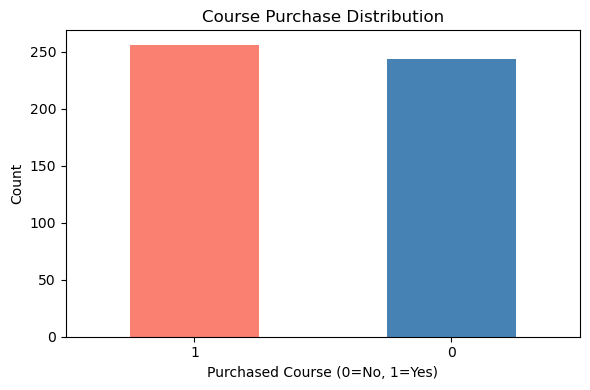

In [8]:
plt.figure(figsize=(6, 4))
df['purchased_course'].value_counts().plot(kind='bar', color=['salmon', 'steelblue'])
plt.title('Course Purchase Distribution')
plt.xlabel('Purchased Course (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

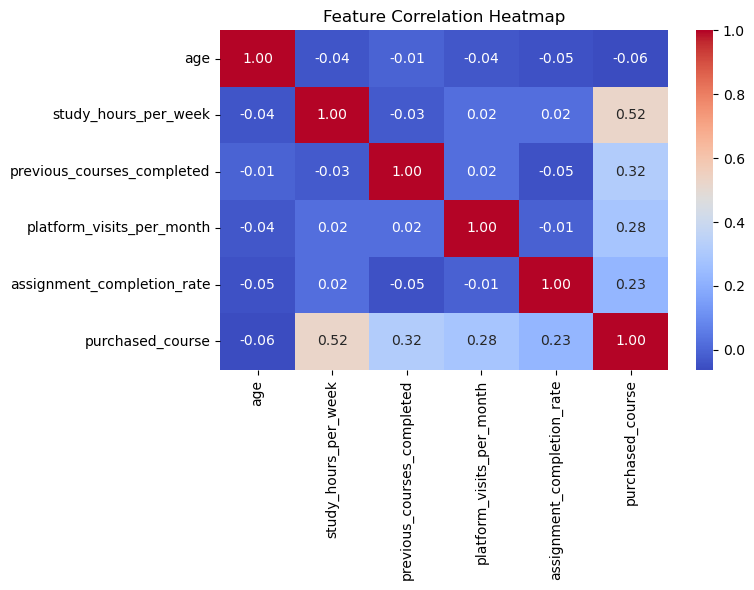

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

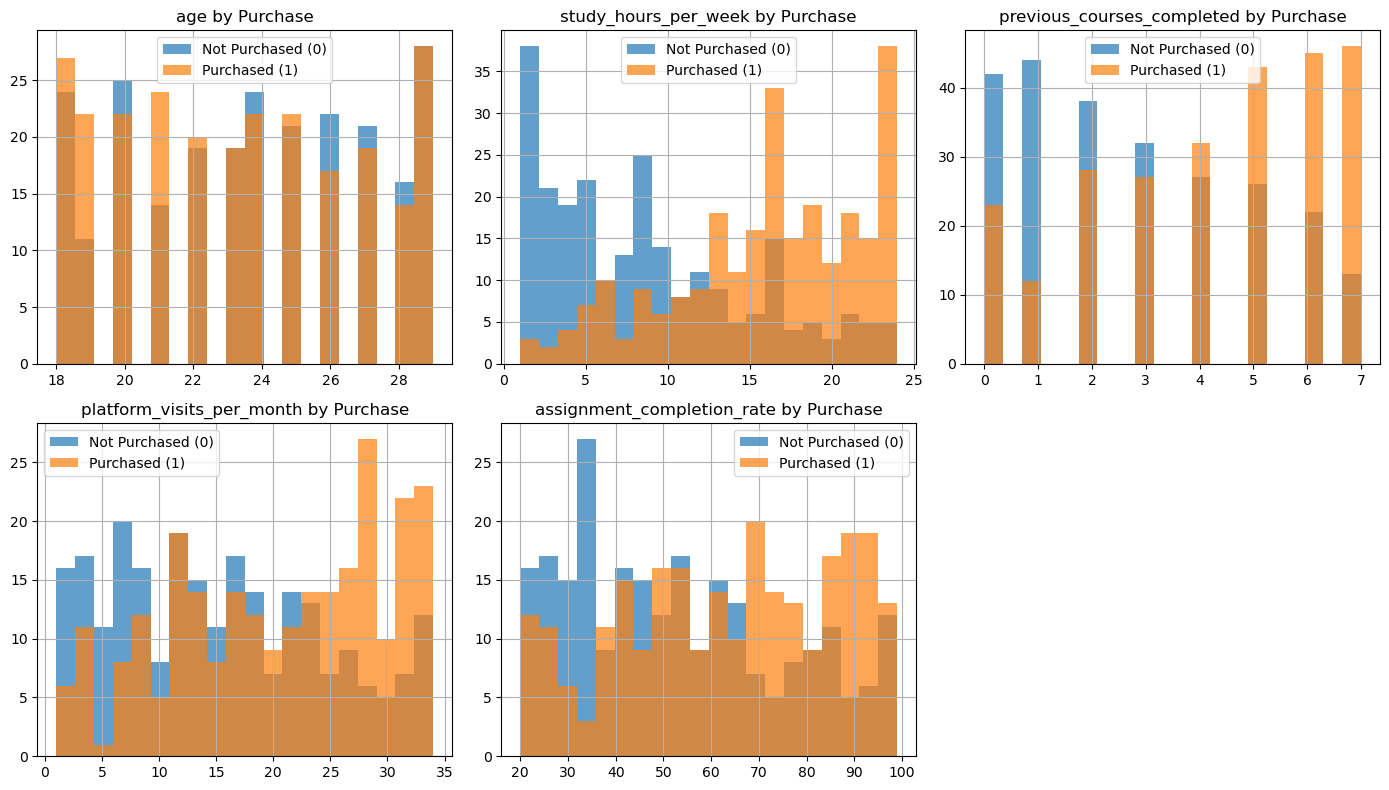

In [10]:
features = ['age', 'study_hours_per_week', 'previous_courses_completed',
            'platform_visits_per_month', 'assignment_completion_rate']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    df.groupby('purchased_course')[feature].hist(ax=axes[i], alpha=0.7, bins=20)
    axes[i].set_title(f'{feature} by Purchase')
    axes[i].legend(['Not Purchased (0)', 'Purchased (1)'])

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

In [11]:
X = df[['age', 'study_hours_per_week', 'previous_courses_completed',
        'platform_visits_per_month', 'assignment_completion_rate']]
y = df['purchased_course']

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

# Feature scaling (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('\n✅ Data preprocessing complete!')

Training samples: 400
Testing samples:  100

✅ Data preprocessing complete!


In [12]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)
print(f'Logistic Regression Accuracy: {lr_acc:.4f} ({lr_acc*100:.2f}%)')

Logistic Regression Accuracy: 0.8400 (84.00%)


In [13]:
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
print(f'Decision Tree Accuracy: {dt_acc:.4f} ({dt_acc*100:.2f}%)')

Decision Tree Accuracy: 0.7800 (78.00%)


In [14]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print(f'Random Forest Accuracy: {rf_acc:.4f} ({rf_acc*100:.2f}%)')

Random Forest Accuracy: 0.8300 (83.00%)


                 Model  Accuracy
0  Logistic Regression      0.84
1        Random Forest      0.83
2        Decision Tree      0.78


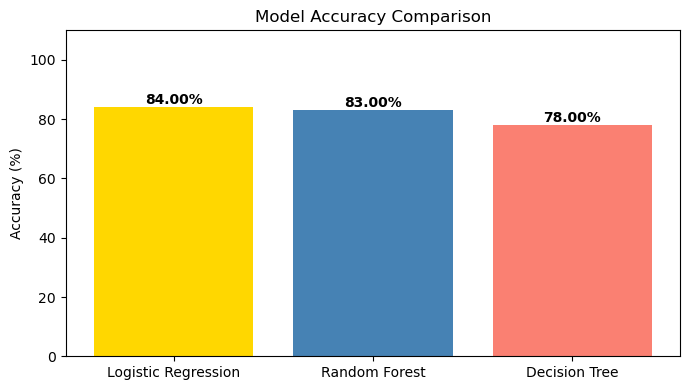

In [15]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [lr_acc, dt_acc, rf_acc]
})
results = results.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(results)

# Bar chart
plt.figure(figsize=(7, 4))
plt.bar(results['Model'], results['Accuracy'] * 100, color=['gold', 'steelblue', 'salmon'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
for i, v in enumerate(results['Accuracy']):
    plt.text(i, v*100 + 1, f'{v*100:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


🏆 Best Model: Logistic Regression

--- Random Forest Classification Report ---
               precision    recall  f1-score   support

Not Purchased       0.82      0.84      0.83        49
    Purchased       0.84      0.82      0.83        51

     accuracy                           0.83       100
    macro avg       0.83      0.83      0.83       100
 weighted avg       0.83      0.83      0.83       100



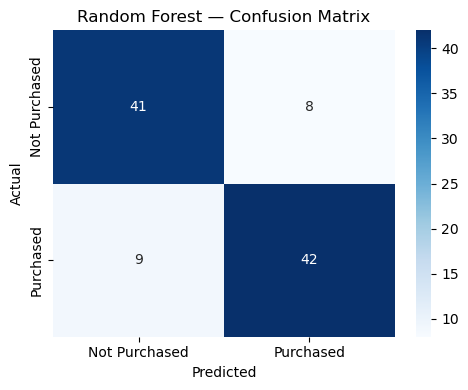

In [16]:
# Best model detailed report
best_model_name = results.iloc[0]['Model']
print(f'\n🏆 Best Model: {best_model_name}')

# Use Random Forest predictions for report (usually best)
print('\n--- Random Forest Classification Report ---')
print(classification_report(y_test, rf_pred, target_names=['Not Purchased', 'Purchased']))

# Confusion Matrix
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Purchased', 'Purchased'],
            yticklabels=['Not Purchased', 'Purchased'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

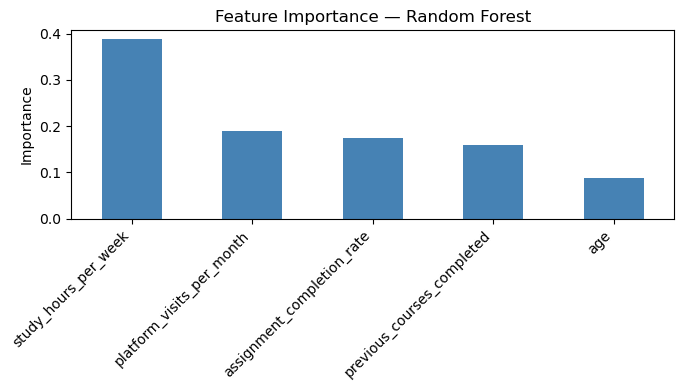

study_hours_per_week          0.387937
platform_visits_per_month     0.189594
assignment_completion_rate    0.175104
previous_courses_completed    0.159717
age                           0.087648
dtype: float64


In [17]:
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
feat_imp.plot(kind='bar', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(feat_imp)

In [18]:
with open('model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('✅ Model saved as model.pkl')
print('✅ Scaler saved as scaler.pkl')
print('\nThese files will be used by your Streamlit app!')

✅ Model saved as model.pkl
✅ Scaler saved as scaler.pkl

These files will be used by your Streamlit app!


In [19]:
with open('model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Example from the task brief:
# Age=22, Study Hours=14, Courses Completed=3, Platform Visits=20, Assignment Completion=85
sample_input = np.array([[22, 14, 3, 20, 85]])

prediction = loaded_model.predict(sample_input)[0]
probability = loaded_model.predict_proba(sample_input)[0]

print('=== Test Prediction ===')
print(f'Input: Age=22, Study Hours=14, Courses=3, Visits=20, Assignment Rate=85')
print(f'Prediction: {"✅ Student Likely to Purchase Course" if prediction == 1 else "❌ Student NOT Likely to Purchase"}')
print(f'Confidence: {max(probability)*100:.1f}%')

=== Test Prediction ===
Input: Age=22, Study Hours=14, Courses=3, Visits=20, Assignment Rate=85
Prediction: ✅ Student Likely to Purchase Course
Confidence: 83.0%


In [20]:
import pickle

# Retrain with current sklearn version
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Save model
with open(r'C:\Users\HP\model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print("✅ model.pkl saved!")

✅ model.pkl saved!
